### **LangGraph Components**

In [39]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults # does live web search
from pprint import pprint

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

chat = ChatOpenAI(model = 'gpt-4o', temperature = 0)
tool = TavilySearchResults(max_results = 5)

print (type(tool))
print (tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


In [ ]:
from langgraph.graph import MessagesState, StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from typing import Literal

class Agent:
    def __init__ (self, chat, tools, system = ''):
        self.system = system

        graph = StateGraph(MessagesState)
        graph.add_node('Large Language Model', self.call_openai)
        graph.add_node('Action', self.take_action)
        
        graph.set_entry_point('Large Language Model')
        graph.add_conditional_edges('Large Language Model', self.thought)
        graph.add_edge('Action', 'Large Language Model')

        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.chat = chat.bind_tools(tools)
    
    def thought(self, state: MessagesState) -> Literal['Action', END]:
        response = state['messages'][-1]
        return 'Action' if len(response.tool_calls) else END
    
    def call_openai(self, state: MessagesState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content = self.system)] + messages
        
        message = self.chat.invoke(messages)
        return {'messages': [message]}
    
    def take_action(self, state: MessagesState):
        tool_calls = state['messages'][-1].tool_calls
        response = []

        for t in tool_calls:
            print (f'Calling: {t}')
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            response.append(ToolMessage(tool_call_id = t['id'], name = t['name'], content = str(result)))
            
        print('Back to the model!')
        return {'messages': response}

In [35]:
prompt = '''You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
'''

AIbot = Agent(chat, [tool], system = prompt)

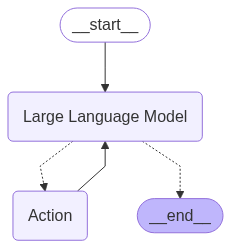

In [27]:
from IPython.display import display, Image

display(Image(AIbot.graph.get_graph().draw_mermaid_png()))

In [45]:
messages = [HumanMessage(content = 'What is the weather in Tampa, South Florida and Da Nang, Viet Nam?')]
response = AIbot.graph.invoke({'messages': messages})

pprint(response['messages'][-1].content)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Tampa weather'}, 'id': 'call_6F9oESfIyj577dL9aXMBbWyr', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'South Florida weather'}, 'id': 'call_LAg0p3gNv2ofhakFs1jzh0G7', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Da Nang weather'}, 'id': 'call_vX7KpXKdlb449FCF6ziRCzq5', 'type': 'tool_call'}
Back to the model!
("Here's the current weather information for the requested locations:\n"
 '\n'
 '1. **Tampa, Florida**:\n'
 '   - The weather in Tampa is currently warm with temperatures around 87°F '
 '(approximately 31°C). There is a chance of scattered storms, and the '
 'humidity is around 77%. '
 '[Source](https://www.timeanddate.com/weather/usa/tampa)\n'
 '\n'
 '2. **South Florida**:\n'
 '   - In South Florida, the weather is generally hot in May with average '
 'temperatures ranging from 21°C to 31°C (approximately 70°F to 88°F). Rain is '
 '

In [44]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = 'Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question.' 
messages = [HumanMessage(content = query)]

response = AIbot.graph.invoke({'messages': messages})
pprint(response['messages'][-1].content)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Super Bowl 2024 winner'}, 'id': 'call_F0W60TXeJ3C8f0SmRJV523ZX', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_DVCBrymQ5YbG5thSn6wXtVxn', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Missouri GDP 2024'}, 'id': 'call_yuQSdiCYpfeN16SRZQmjP0SJ', 'type': 'tool_call'}
Back to the model!
('1. **Who won the Super Bowl in 2024?**\n'
 '   - The Kansas City Chiefs won the Super Bowl in 2024, defeating the San '
 'Francisco 49ers 25-22 in overtime.\n'
 '\n'
 "2. **In what state is the winning team's headquarters located?**\n"
 "   - The Kansas City Chiefs' headquarters is located in Kansas City, "
 'Missouri.\n'
 '\n'
 '3. **What is the GDP of that state?**\n'
 "   - Missouri's GDP in the fourth quarter of 2024 was approximately $460.7 "
 'billion.')
